In [1]:
# ==============================================================================
# 0. Environment Setup & Visual Configuration
# ==============================================================================
!pip install --quiet astroML emcee corner scipy matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Enable high-resolution plots for Retina / 4K displays
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Standardize plot styling across the entire notebook
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'lines.linewidth': 2.0
})

# Compatibility patch: astroML.stats.random.linear_gen with modern SciPy (>= 1.9)
try:
    from astroML.stats.random import linear_gen
    def _fixed_linear_rvs(self, a, b, c, size=None, random_state=None):
        if size is None:
            size = getattr(self, '_size', 1)
        rng = np.random.default_rng(random_state)
        mu = 0.5 * (a + b)
        W = (b - a)
        x0 = 1.0 / (c * W) - mu
        r = rng.random(size)
        return -x0 + np.sqrt(2.0 * r / c + a * a + 2.0 * a * x0 + x0 * x0)
    linear_gen._rvs = _fixed_linear_rvs
    linear_gen._scipy_patched = True
except Exception:
    pass

print("✨ Environment configured: High-DPI graphics enabled and astroML patch applied.")


✨ Environment configured: High-DPI graphics enabled and astroML patch applied.


# Bayesian Statistical Inference: Parameter Estimation in Astronomy

---

### 📋 Table of Contents
1. [Theoretical Foundations: Bayes' Theorem](#0-foundations)
2. [Parameter Estimation for a Gaussian Distribution](#1-gaussian)
   - *Known errors $\sigma_i$ (Weighted Mean)*
   - *Unknown $\sigma$: Joint Estimation & Student-t distribution*
3. [Modern Computational Inference: MCMC with `emcee`](#2-mcmc)
4. [Parameter Estimation: Gaussian Signal + Uniform Background](#3-background)
5. [Regression Preview: Gaussian vs. Poisson Likelihood](#4-regression)
6. [Mixture Models: Outlier Rejection & Reliability Weights](#5-outliers)
7. [Hands-On Student Exercises & Key Takeaways](#6-exercises)

---

<a id="0-foundations"></a>
## 0. Theoretical Foundations: Bayes' Theorem

In the Bayesian framework, probability represents a **degree of belief** or plausible reasoning given incomplete information, rather than the long-run relative frequency of repeatable events.

> ### 📐 Bayes' Theorem
> Given observed data $D$, model parameters $\boldsymbol{\theta}$, and contextual/background information $I$:
> 
> $$\boxed{ p(\boldsymbol{\theta} \mid D, I) = \frac{p(D \mid \boldsymbol{\theta}, I) \, p(\boldsymbol{\theta} \mid I)}{p(D \mid I)} }$$

### Breakdown of Components:
* **$p(\boldsymbol{\theta} \mid D, I)$ — The Posterior PDF:** Our updated state of knowledge about parameters $\boldsymbol{\theta}$ after incorporating the experimental data.
* **$p(D \mid \boldsymbol{\theta}, I)$ — The Likelihood Function $\mathcal{L}(\boldsymbol{\theta})$:** The probability of observing data $D$ as a function of the model parameters $\boldsymbol{\theta}$.
* **$p(\boldsymbol{\theta} \mid I)$ — The Prior PDF:** Our state of knowledge about $\boldsymbol{\theta}$ prior to observing the current data (encapsulating physics constraints, previous experiments, or symmetries).
* **$p(D \mid I)$ — The Evidence (Marginal Likelihood):** A normalization integral across the entire parameter space:
  $$p(D \mid I) = \int p(D \mid \boldsymbol{\theta}, I) \, p(\boldsymbol{\theta} \mid I) \, d\boldsymbol{\theta}$$
  *(For parameter estimation with a fixed model, this acts as a constant scaling factor; in Bayesian model comparison, it is the decisive quantity).*

> #### 🔄 The Bayesian Inference Workflow
> 1. **Generative Model:** Formulate the likelihood $\mathcal{L}(\boldsymbol{\theta}) = p(D \mid \boldsymbol{\theta}, I)$.
> 2. **Prior Assignment:** Define $p(\boldsymbol{\theta} \mid I)$ (informative vs uninformative / Jeffreys / conjugate).
> 3. **Posterior Evaluation:** Compute $p(\boldsymbol{\theta} \mid D, I) \propto \mathcal{L}(\boldsymbol{\theta}) \times p(\boldsymbol{\theta} \mid I)$ analytically, via grid evaluation, or via MCMC.
> 4. **Marginalization & Summary:** Integrate out nuisance parameters and compute credible intervals ($68.3\%$, $95.4\%$).


<a id="1-gaussian"></a>
## 1. Parameter Estimation for a Gaussian Distribution

### A. Known Measurement Errors (Heteroscedastic Gaussian Errors)
Consider $N$ independent measurements, $\{x_i\}$, of a single physical quantity (e.g. the length of a rod, or the parallax of a star). The errors are Gaussian, independent, and known for each measurement as $\sigma_i$. We seek the posterior pdf for the true value $\mu$: $p(\mu \mid \{x_i\}, \{\sigma_i\}, I)$.

The data likelihood is the product of individual Gaussian probabilities:
$$p(\{x_i\} \mid \mu, \{\sigma_i\}, I) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\sigma_i} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma_i^2} \right)$$

Adopting a flat (uniform) prior on $\mu$ over a sufficiently wide range $[\mu_{\min}, \mu_{\max}]$:
$$p(\mu \mid I) = C = (\mu_{\max} - \mu_{\min})^{-1}$$

The log-posterior is:
$$L_p = \ln p(\mu \mid \{x_i\}, \{\sigma_i\}, I) = \text{constant} - \sum_{i=1}^{N} \frac{(x_i - \mu)^2}{2\sigma_i^2}$$

Setting $\left.\frac{d L_p}{d\mu}\right|_{\mu = \mu_0} = 0$, we find the Maximum A Posteriori (MAP) estimator:

> #### 🎯 Exact Analytical Result (Known $\sigma_i$)
> 
> $$\boxed{ \mu_0 = \frac{\sum_{i=1}^{N} w_i x_i}{\sum_{i=1}^{N} w_i} }, \quad \text{where } w_i = \frac{1}{\sigma_i^2}$$
> 
> The posterior uncertainty (width) is:
> 
> $$\boxed{ \sigma_\mu = \left( \sum_{i=1}^{N} w_i \right)^{-1/2} }$$

---

### B. Unknown $\sigma$: Joint Estimation of $(\mu, \sigma)$
Now suppose a sample $\{x_i\}$ of size $N$ is drawn from a Gaussian $\mathcal{N}(\mu, \sigma)$ where **both** the mean $\mu$ and intrinsic dispersion $\sigma$ are unknown.

> #### ⚠️ Important Conceptual Distinction
> The posterior for $\mu$ is Gaussian *only* when $\sigma$ is known a priori, or in the asymptotic limit $N \to \infty$. When $\sigma$ is estimated from the sample and $N$ is small, marginalizing over $\sigma$ yields **Student's $t$-distribution** with heavier tails!

Adopting a uniform prior for $\mu$ and **Jeffreys prior** for scale ($p(\sigma \mid I) \propto 1/\sigma$, equivalent to flat in $\ln\sigma$):
$$p(\mu, \sigma \mid I) \propto \frac{1}{\sigma}$$

The joint posterior pdf is:
$$p(\{x_i\} \mid \mu, \sigma, I) \, p(\mu, \sigma \mid I) \propto \frac{1}{\sigma^{N+1}} \prod_{i=1}^{N} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)$$

Defining $V = \frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2 = \frac{N-1}{N} s^2$, where $s$ is the sample standard deviation, the log-posterior is:

$$\boxed{ L_p = \ln p(\mu, \sigma \mid \{x_i\}, I) = \text{constant} - (N+1)\ln\sigma - \frac{N}{2\sigma^2}\left((\bar{x} - \mu)^2 + V\right) }$$

The three quantities $(N, \bar{x}, V)$ are the **sufficient statistics** that capture 100% of the information content in the dataset.


<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_3992773/1081171715.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  function for :math:`\mu` and :math:`\sigma`, :math:`L_p(\mu,\sigma)`
/home/mardom/anaconda3/envs/transformers/lib/python3.14/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


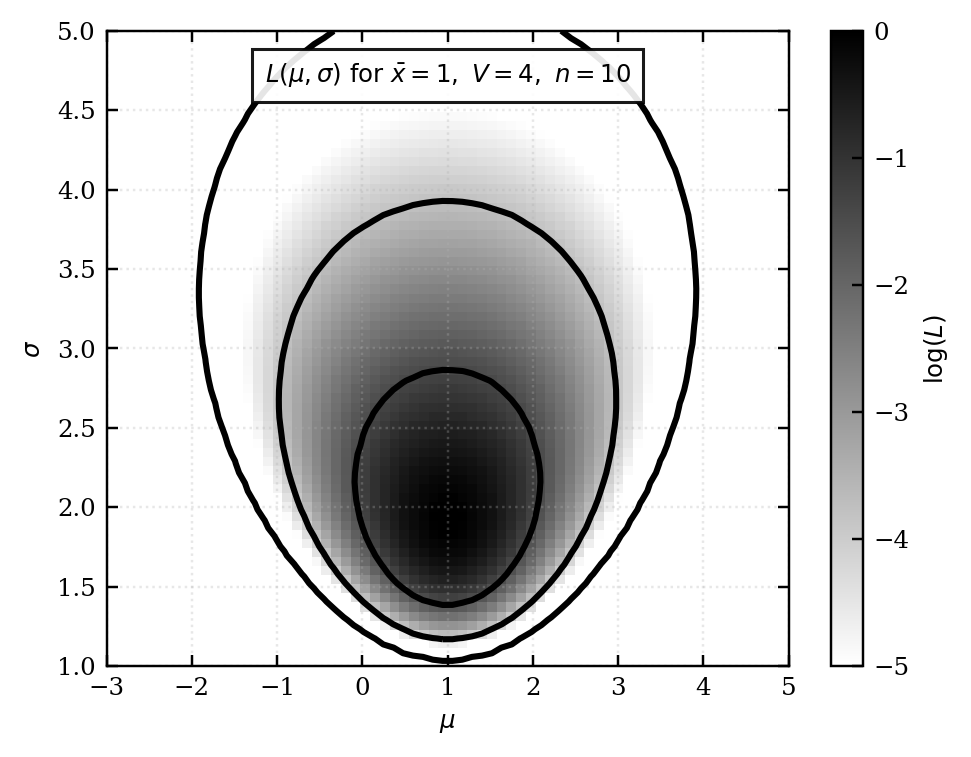

In [2]:
"""
Log-likelihood for Gaussian Distribution
----------------------------------------
Figure5.4
An illustration of the logarithm of the posterior probability density
function for :math:`\mu` and :math:`\sigma`, :math:`L_p(\mu,\sigma)`
(see eq. 5.58) for data drawn from a Gaussian distribution and N = 10, x = 1,
and V = 4. The maximum of :math:`L_p` is renormalized to 0, and color coded as
shown in the legend. The maximum value of :math:`L_p` is at :math:`\mu_0 = 1.0`
and :math:`\sigma_0 = 1.8`. The contours enclose the regions that contain
0.683, 0.955, and 0.997 of the cumulative (integrated) posterior probability.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML.plotting.mcmc import convert_to_stdev

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def gauss_logL(xbar, V, n, sigma, mu):
    """Equation 5.57: gaussian likelihood"""
    return (-(n + 1) * np.log(sigma)
            - 0.5 * n * ((xbar - mu) ** 2 + V) / sigma ** 2)

#------------------------------------------------------------
# Define the grid and compute logL
sigma = np.linspace(1, 5, 70)
mu = np.linspace(-3, 5, 70)
xbar = 1
V = 4
n = 10

logL = gauss_logL(xbar, V, n, sigma[:, np.newaxis], mu)
logL -= logL.max()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 3.75))
plt.imshow(logL, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           cmap=plt.cm.binary,
           aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.contour(mu, sigma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='k')

plt.text(0.5, 0.93, r'$L(\mu,\sigma)\ \mathrm{for}\ \bar{x}=1,\ V=4,\ n=10$',
         bbox=dict(ec='k', fc='w', alpha=0.9),
         ha='center', va='center', transform=plt.gca().transAxes)

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')

plt.show()

The region of the $(\mu, \sigma)$ plane which encloses a given cumulative probability for
the posterior pdf (or regions in the case of multimodal posterior pdfs) can be found
by the following simple numerical procedure. The posterior pdf up to a normalization constant is simply $exp(L_p)$. The product of $exp(L_p)$
and the pixel area (assuming sufficiently small pixels so that no interpolation is necessary) can be summed up to determine the normalization constant (the integral of the posterior pdf over all model parameters must be unity). The renormalized posterior pdf can be sorted, while keeping track of the corresponding pixel for each
value, and the corresponding cumulative distribution computed. Given a threshold
of p%, all the pixels for which the cumulative probability is larger than $(1 − p/100)$
will outline the required region.

For a given $\sigma = \sigma'$ , the maximum value of $L_p$ is found along the $\mu = \mu_0 = \bar(x)$ line, and the posterior probability $p(\mu|\sigma = \sigma')$ is a Gaussian. However, now we do not know the true value of $\sigma$ . When deriving the posterior probability $p(\mu)$, we need to marginalize (integrate) over all
possible values of $\sigma$.

$$p(\mu | {x_{i}, I})=\int_{0}^{\infty} p(\mu, \sigma | {x_{i}, I}) d\sigma \propto [1+\frac{(\bar{x}-\mu)^{2}}{V}]^{-N/2}$$

It is easy to show that this result corresponds to Student’s t distribution with $k = N − 1$ degrees of freedom for the variable $t = (x − \mu)/(s / N)$. Had we assumed a uniform prior
for $\sigma$ , we would have obtained Student’s t distribution with $k = (N − 2)$ degrees of
freedom (the difference between these two solutions becomes negligible for large N).

Analogously to determining $p(\mu|{x_i}, I )$, the posterior pdf for $\sigma$ is derived using
marginalization,

$$p(\sigma| x_{i}, I) = \int_{0}^{\infty} p(\mu, \sigma | x_{i}, I) d\mu \propto \frac{1}{\sigma^N}exp(\frac{-NV}{2\sigma^2})$$




<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_3992773/2424429621.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  function :math:`p(\mu|\{x_i\},I)` described by eq. 5.60, for N = 10, x = 1 and


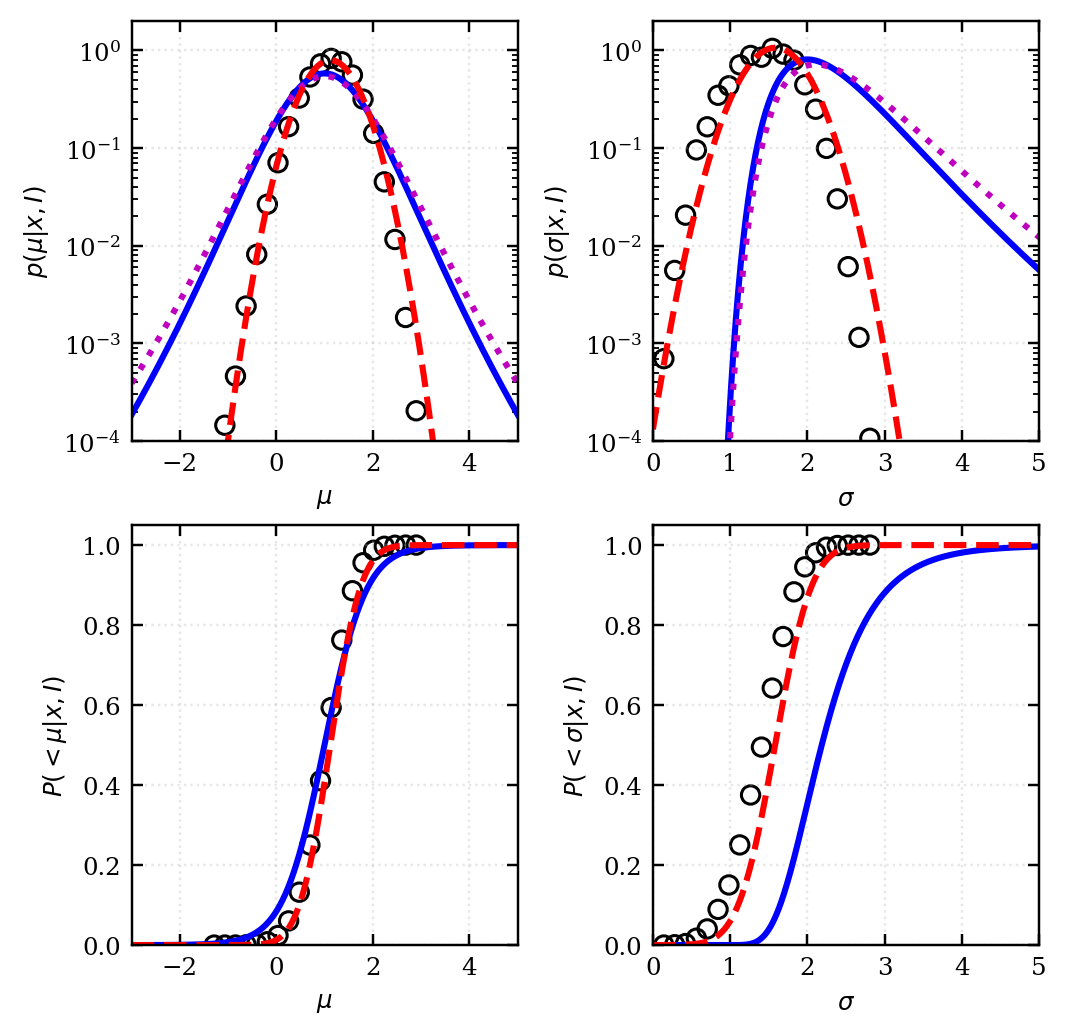

In [3]:
"""
Posterior for Gaussian Distribution
-----------------------------------
Figure 5.5
The solid line in the top-left panel shows the posterior probability density
function :math:`p(\mu|\{x_i\},I)` described by eq. 5.60, for N = 10, x = 1 and
V = 4 (integral over :math:`\sigma` for the two-dimensional distribution shown
in figure 5.4). The dotted line shows an equivalent result when the prior for
:math:`\sigma` is uniform instead of proportional to :math:`\sigma - 1`.
The dashed line shows the Gaussian distribution with parameters given by
eqs. 3.31 and 3.34. For comparison, the circles illustrate the distribution
of the bootstrap estimates for the mean given by eq. 3.31. The solid line in
the top-right panel shows the posterior probability density function
:math:`p(\sigma|\{xi\},I)` described by eq. 5.62 (integral over :math:`\mu`
for the two-dimensional distribution shown in figure 5.4). The dotted line
shows an equivalent result when the prior for :math:`\sigma` is uniform.
The dashed line shows a Gaussian distribution with parameters given by
eqs. 3.32 and 3.35. The circles illustrate the distribution of the bootstrap
estimates for :math:`\sigma` given by eq. 3.32. The bottom two panels show
the corresponding cumulative distributions for solid and dashed lines,
and for bootstrap estimates, from the top panel.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML.stats import mean_sigma
from astroML.resample import bootstrap

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


#------------------------------------------------------------
# Define functions for computations below
#  These are expected analytic fits to the posterior distributions
def compute_pmu(mu, xbar, V, n):
    return (1 + (xbar - mu) ** 2 / V) ** (-0.5 * n)


def compute_pmu_alt(mu, xbar, V, n):
    return (1 + (xbar - mu) ** 2 / V) ** (-0.5 * (n - 1))


def compute_psig(sig, V, n):
    return (sig ** -n) * np.exp(-0.5 * n * V / sig ** 2)


def compute_psig_alt(sig, V, n):
    return (sig ** -(n - 1)) * np.exp(-0.5 * n * V / sig ** 2)


def gaussian(x, mu, sigma):
    return np.exp(-0.5 * (x - mu) ** 2 / sigma ** 2)


#------------------------------------------------------------
# Draw a random sample from the distribution, and compute
# some quantities
n = 10
xbar = 1
V = 4
sigma_x = np.sqrt(V)

np.random.seed(10)
xi = np.random.normal(xbar, sigma_x, size=n)

mu_mean, sig_mean = mean_sigma(xi, ddof=1)

# compute the analytically expected spread in measurements
mu_std = sig_mean / np.sqrt(n)
sig_std = sig_mean / np.sqrt(2 * (n - 1))

#------------------------------------------------------------
# bootstrap estimates
mu_bootstrap, sig_bootstrap = bootstrap(xi, int(1E6), mean_sigma,
                                        kwargs=dict(ddof=1, axis=1))

#------------------------------------------------------------
# Compute analytic posteriors

# distributions for the mean
mu = np.linspace(-3, 5, 1000)
dmu = mu[1] - mu[0]

pmu = compute_pmu(mu, 1, 4, 10)
pmu /= (dmu * pmu.sum())

pmu2 = compute_pmu_alt(mu, 1, 4, 10)
pmu2 /= (dmu * pmu2.sum())

pmu_norm = gaussian(mu, mu_mean, mu_std)
pmu_norm /= (dmu * pmu_norm.sum())

mu_hist, mu_bins = np.histogram(mu_bootstrap, 20)
mu_dbin = np.diff(mu_bins).astype(float)
mu_hist = mu_hist / mu_dbin / mu_hist.sum()

# distributions for the standard deviation
sig = np.linspace(1E-4, 8, 1000)
dsig = sig[1] - sig[0]
psig = compute_psig(sig, 4, 10)
psig /= (dsig * psig.sum())

psig2 = compute_psig_alt(sig, 4, 10)
psig2 /= (dsig * psig2.sum())

psig_norm = gaussian(sig, sig_mean, sig_std)
psig_norm /= (dsig * psig_norm.sum())

sig_hist, sig_bins = np.histogram(sig_bootstrap, 20)
sig_dbin = np.diff(sig_bins).astype(float)
sig_hist = sig_hist / sig_dbin / sig_hist.sum()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(wspace=0.35, right=0.95,
                    hspace=0.2, top=0.95)

# plot posteriors for mu
ax1 = plt.subplot(221, yscale='log')
ax1.plot(mu, pmu, '-b')
ax1.plot(mu, pmu2, ':m')
ax1.plot(mu, pmu_norm, '--r')
ax1.scatter(mu_bins[1:] - 0.5 * mu_dbin, mu_hist,
            edgecolor='k', facecolor='none')

ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$p(\mu|x,I)$')

ax2 = plt.subplot(223, sharex=ax1)
ax2.plot(mu, pmu.cumsum() * dmu, '-b')
ax2.plot(mu, pmu_norm.cumsum() * dmu, '--r')
ax2.scatter(mu_bins[1:] - 0.5 * mu_dbin, mu_hist.cumsum() * mu_dbin,
            edgecolor='k', facecolor='none')
ax2.set_xlim(-3, 5)

ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel(r'$P(<\mu|x,I)$')

# plot posteriors for sigma
ax3 = plt.subplot(222, sharey=ax1)
ax3.plot(sig, psig, '-b')
ax3.plot(sig, psig2, ':m')
ax3.plot(sig, psig_norm, '--r')
ax3.scatter(sig_bins[1:] - 0.5 * sig_dbin, sig_hist,
            edgecolor='k', facecolor='none')
ax3.set_ylim(1E-4, 2)

ax3.set_xlabel(r'$\sigma$')
ax3.set_ylabel(r'$p(\sigma|x,I)$')

ax4 = plt.subplot(224, sharex=ax3, sharey=ax2)
ax4.plot(sig, psig.cumsum() * dsig, '-b')
ax4.plot(sig, psig_norm.cumsum() * dsig, '--r')
ax4.scatter(sig_bins[1:] - 0.5 * sig_dbin, sig_hist.cumsum() * sig_dbin,
            edgecolor='k', facecolor='none')
ax4.set_ylim(0, 1.05)
ax4.set_xlim(0, 5)

ax4.set_xlabel(r'$\sigma$')
ax4.set_ylabel(r'$P(<\sigma|x,I)$')

plt.show()


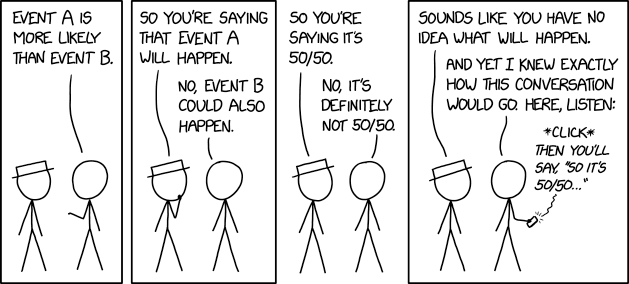

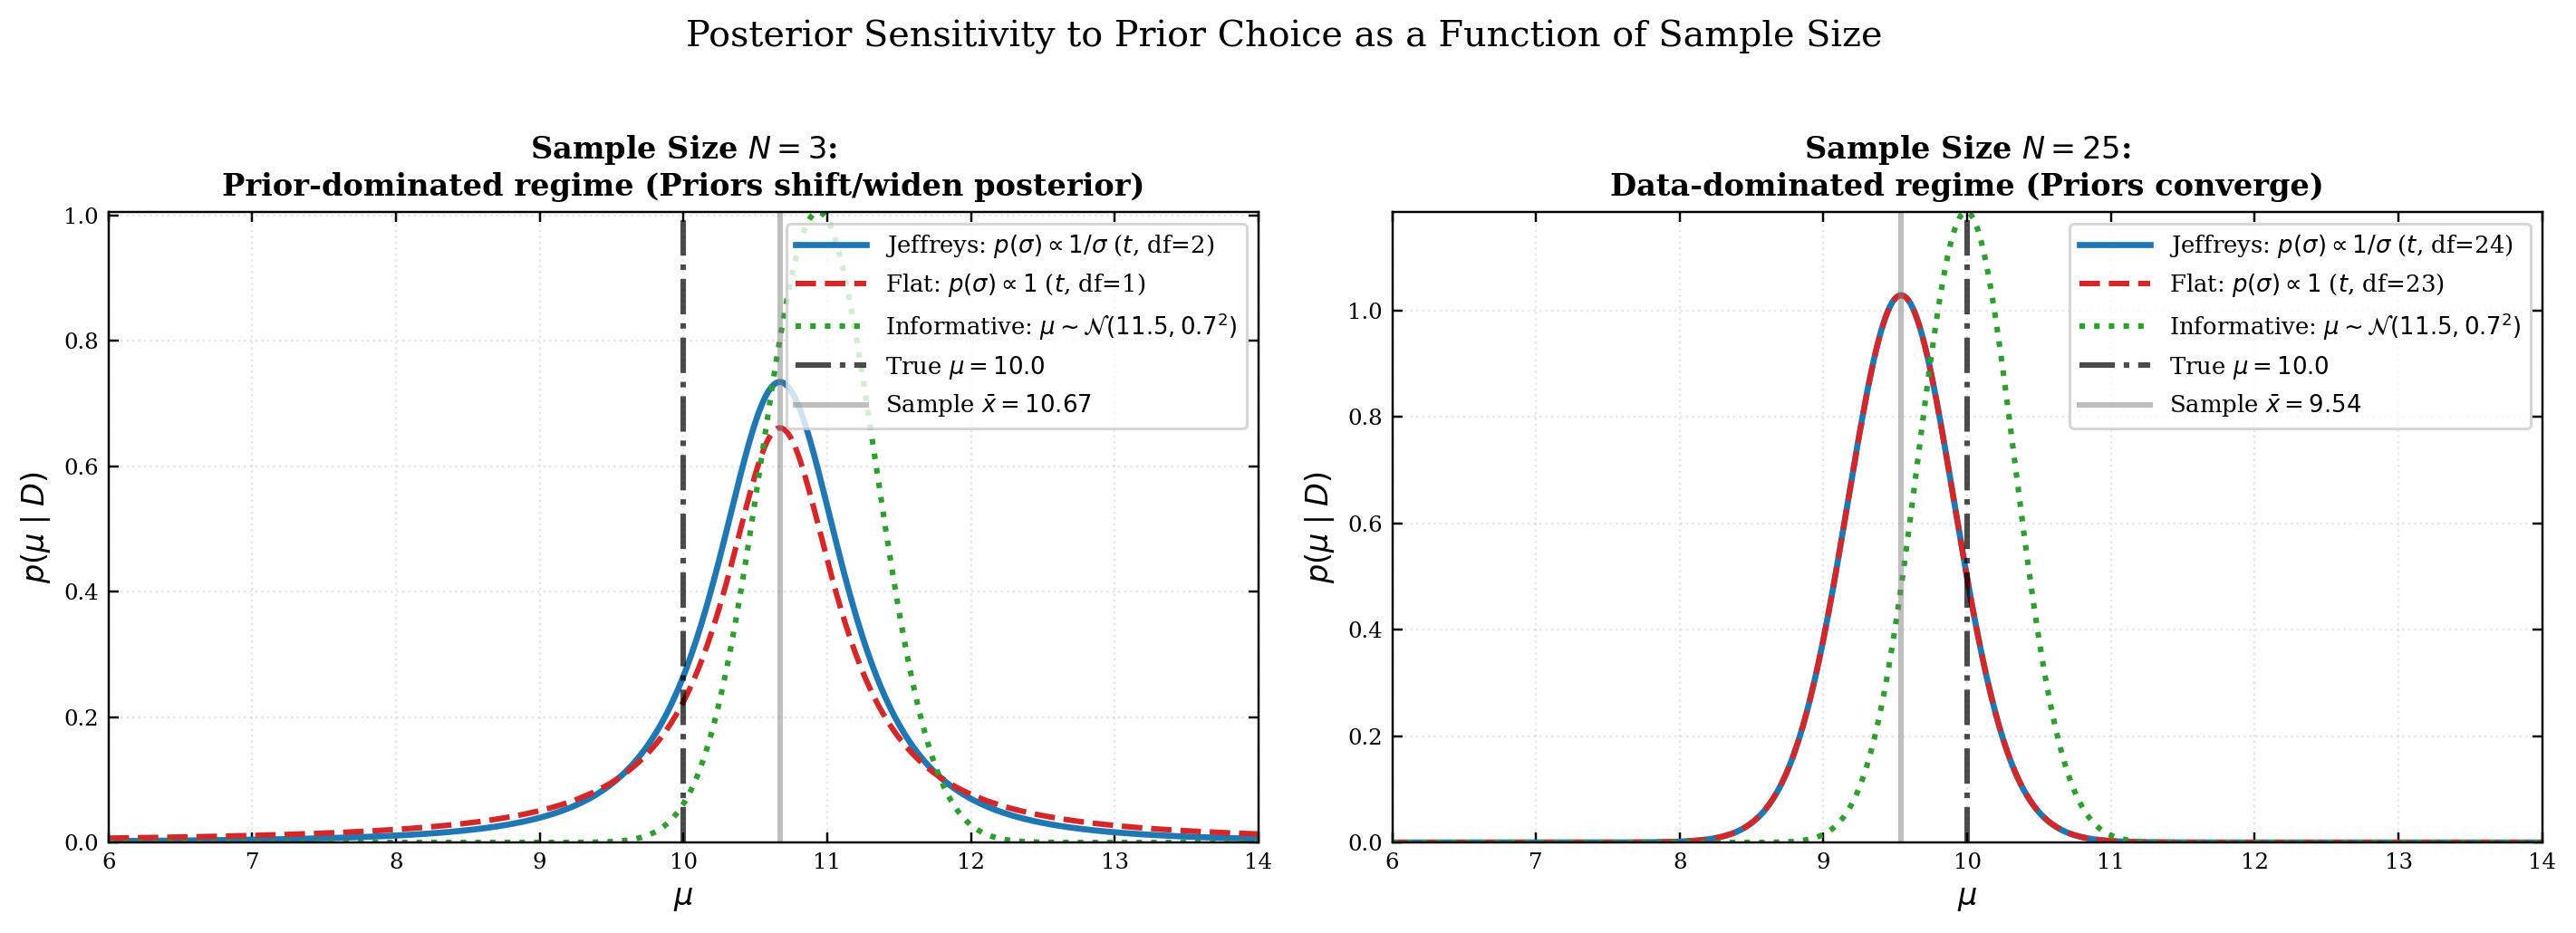

In [4]:
# ==============================================================================
# Visual Demonstration: Prior Sensitivity for Small (N=3) vs Large (N=25) Samples
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

def plot_prior_comparison():
    true_mu = 10.0
    true_sigma = 2.0
    mu_grid = np.linspace(6, 14, 500)
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
    
    for ax, N_samples in zip(axes, [3, 25]):
        data = np.random.normal(true_mu, true_sigma, N_samples)
        x_bar = np.mean(data)
        s = np.std(data, ddof=1)
        scale = s / np.sqrt(N_samples)
        
        # 1. Jeffreys prior: p(sigma) ~ 1/sigma -> Student-t with df = N - 1
        post_jeffreys = stats.t.pdf(mu_grid, df=N_samples - 1, loc=x_bar, scale=scale)
        
        # 2. Flat prior on sigma: p(sigma) ~ const -> Student-t with df = N - 2 (for N >= 3)
        df_flat = max(1, N_samples - 2)
        post_flat = stats.t.pdf(mu_grid, df=df_flat, loc=x_bar, scale=scale)
        
        # 3. Informative prior: mu ~ N(11.5, 0.7^2)
        prior_mu_mean, prior_mu_std = 11.5, 0.7
        post_var_inf = 1.0 / (N_samples / s**2 + 1.0 / prior_mu_std**2)
        post_mean_inf = post_var_inf * (N_samples * x_bar / s**2 + prior_mu_mean / prior_mu_std**2)
        post_informative = stats.norm.pdf(mu_grid, post_mean_inf, np.sqrt(post_var_inf))
        
        # Plot curves using raw f-strings to avoid any escape issues in matplotlib
        ax.plot(mu_grid, post_jeffreys, label=fr'Jeffreys: $p(\sigma) \propto 1/\sigma$ ($t$, df={N_samples-1})', lw=2.2, color='#1f77b4')
        ax.plot(mu_grid, post_flat, label=fr'Flat: $p(\sigma) \propto 1$ ($t$, df={df_flat})', lw=2, linestyle='--', color='#d62728')
        ax.plot(mu_grid, post_informative, label=r'Informative: $\mu \sim \mathcal{N}(11.5, 0.7^2)$', lw=2, linestyle=':', color='#2ca02c')
        ax.axvline(true_mu, color='black', alpha=0.7, linestyle='-.', label=fr'True $\mu = {true_mu}$')
        ax.axvline(x_bar, color='gray', alpha=0.5, linestyle='-', label=fr'Sample $\bar{{x}} = {x_bar:.2f}$')
        
        regime = "Prior-dominated regime (Priors shift/widen posterior)" if N_samples <= 5 else "Data-dominated regime (Priors converge)"
        ax.set_title(f"Sample Size $N = {N_samples}$:\n{regime}", fontsize=11, fontweight='bold')
        ax.set_xlabel(r"$\mu$", fontsize=11)
        ax.set_ylabel(r"$p(\mu \mid D)$", fontsize=11)
        ax.legend(loc='upper right', fontsize=8.5, frameon=True)
        ax.grid(True, alpha=0.3)
        
    plt.suptitle("Posterior Sensitivity to Prior Choice as a Function of Sample Size", fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

plot_prior_comparison()


<a id="2-mcmc"></a>
## 2. Modern Computational Inference: Markov Chain Monte Carlo (MCMC)

Evaluating the posterior probability on a discrete multidimensional grid (as in Figure 5.4) scales exponentially with the number of parameters $D$ ($N_{\text{eval}} = G^D$). For $D > 3$, grid evaluation becomes computationally prohibitive.

In modern astronomical research, we sample from the posterior distribution using **Markov Chain Monte Carlo (MCMC)** algorithms. Below, we solve the exact same two-parameter inference problem ($\mu, \sigma$ unknown) using the affine-invariant ensemble sampler **`emcee`** (Foreman-Mackey et al. 2013) and visualize the marginalized posterior with **`corner`**.


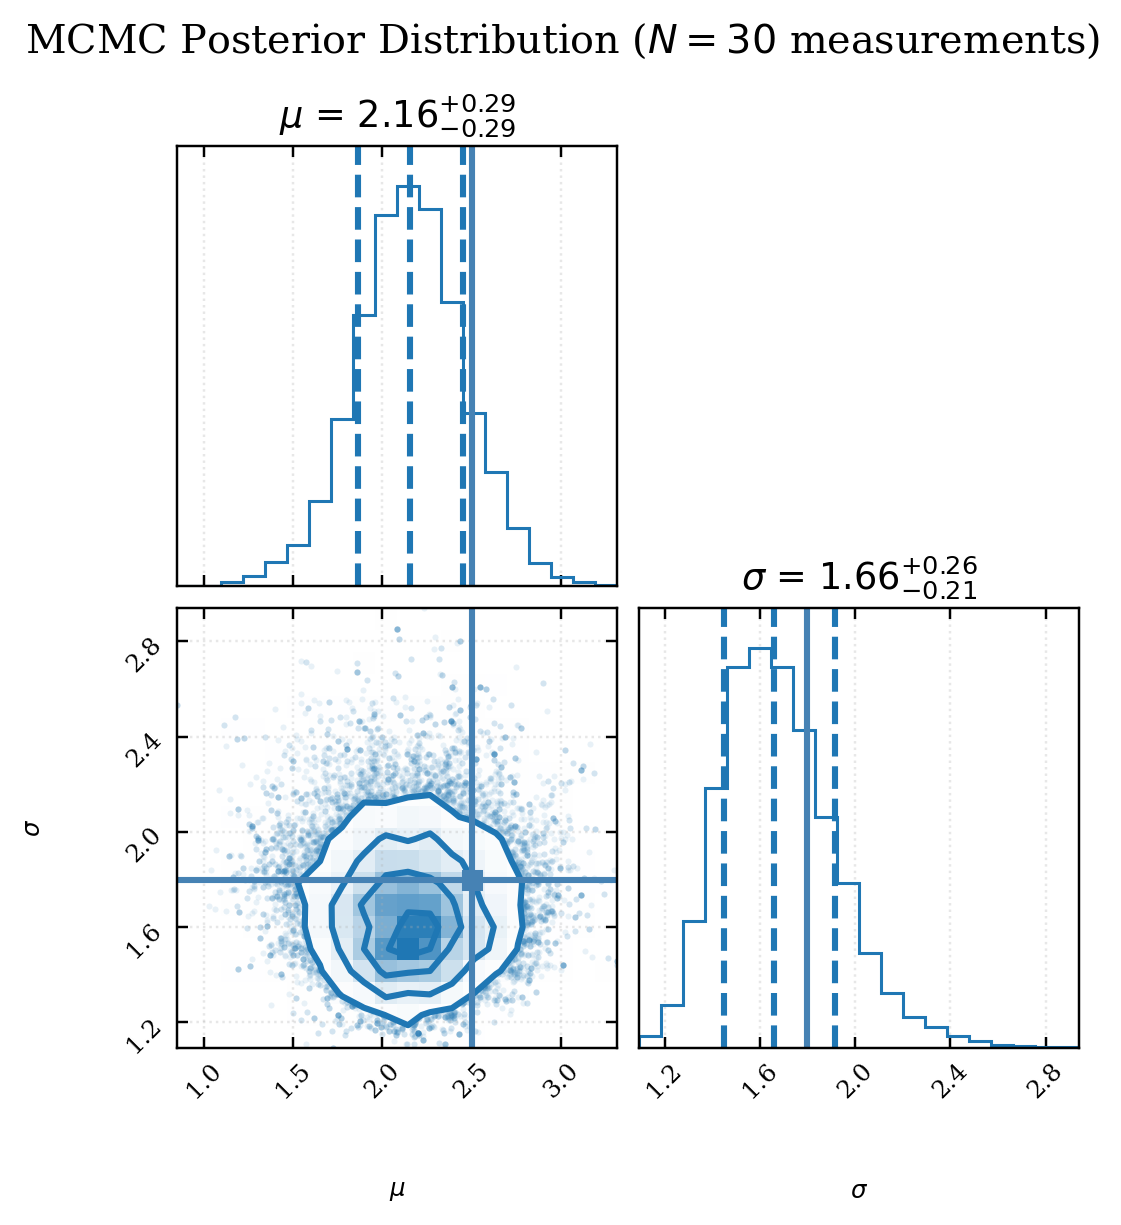

In [5]:
# ==============================================================================
# MCMC Parameter Estimation with emcee and corner.py
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

try:
    import emcee
    import corner
except ImportError:
    print("⚠️ Required packages ('emcee' or 'corner') not found.")
    print("Please run Cell 0 at the top of this notebook: !pip install emcee corner")
    emcee = None
    corner = None

if emcee is not None and corner is not None:
    # 1. Generate synthetic dataset
    np.random.seed(42)
    true_mu, true_sigma = 2.5, 1.8
    N_points = 30
    data = np.random.normal(true_mu, true_sigma, N_points)

    # 2. Define Log-Prior, Log-Likelihood, and Log-Posterior
    def log_prior(theta):
        mu, sigma = theta
        # Flat prior on mu, Jeffreys prior on sigma: p(sigma) ~ 1/sigma => ln p = -ln(sigma)
        if -10.0 < mu < 10.0 and 0.01 < sigma < 10.0:
            return -np.log(sigma)
        return -np.inf

    def log_likelihood(theta, data):
        mu, sigma = theta
        N = len(data)
        return -0.5 * N * np.log(2 * np.pi * sigma**2) - np.sum((data - mu)**2) / (2 * sigma**2)

    def log_posterior(theta, data):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta, data)

    # 3. Initialize walkers and run MCMC
    ndim, nwalkers = 2, 32
    initial_guess = [np.mean(data), np.std(data, ddof=1)]
    p0 = initial_guess + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(data,))

    # Burn-in
    state = sampler.run_mcmc(p0, 300, progress=False)
    sampler.reset()

    # Production run
    sampler.run_mcmc(state, 1000, progress=False)
    flat_samples = sampler.get_chain(flat=True)

    # 4. Corner plot: 1D marginals and 2D joint posterior contours
    fig = corner.corner(
        flat_samples, 
        labels=[r"$\mu$", r"$\sigma$"], 
        truths=[true_mu, true_sigma],
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        color='#1f77b4'
    )
    plt.suptitle(f"MCMC Posterior Distribution ($N={N_points}$ measurements)", y=1.03, fontsize=13)
    plt.show()


<a id="3-background"></a>
## 3. Parameter Estimation for a Gaussian and a Uniform Background

We now solve a parameter estimation problem involving a mixture of a Gaussian distribution and a uniform distribution across an interval of width $W$. This example illustrates **parameter covariance** and **marginalization over nuisance parameters**.

The likelihood of obtaining a measurement $x_i$ is given by:

$$p(x_i \mid A, \mu, \sigma) = \frac{A}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right) + \frac{1 - A}{W}$$

where $A$ is the fraction of measurements belonging to the Gaussian component, and $(1 - A)$ is the background fraction.


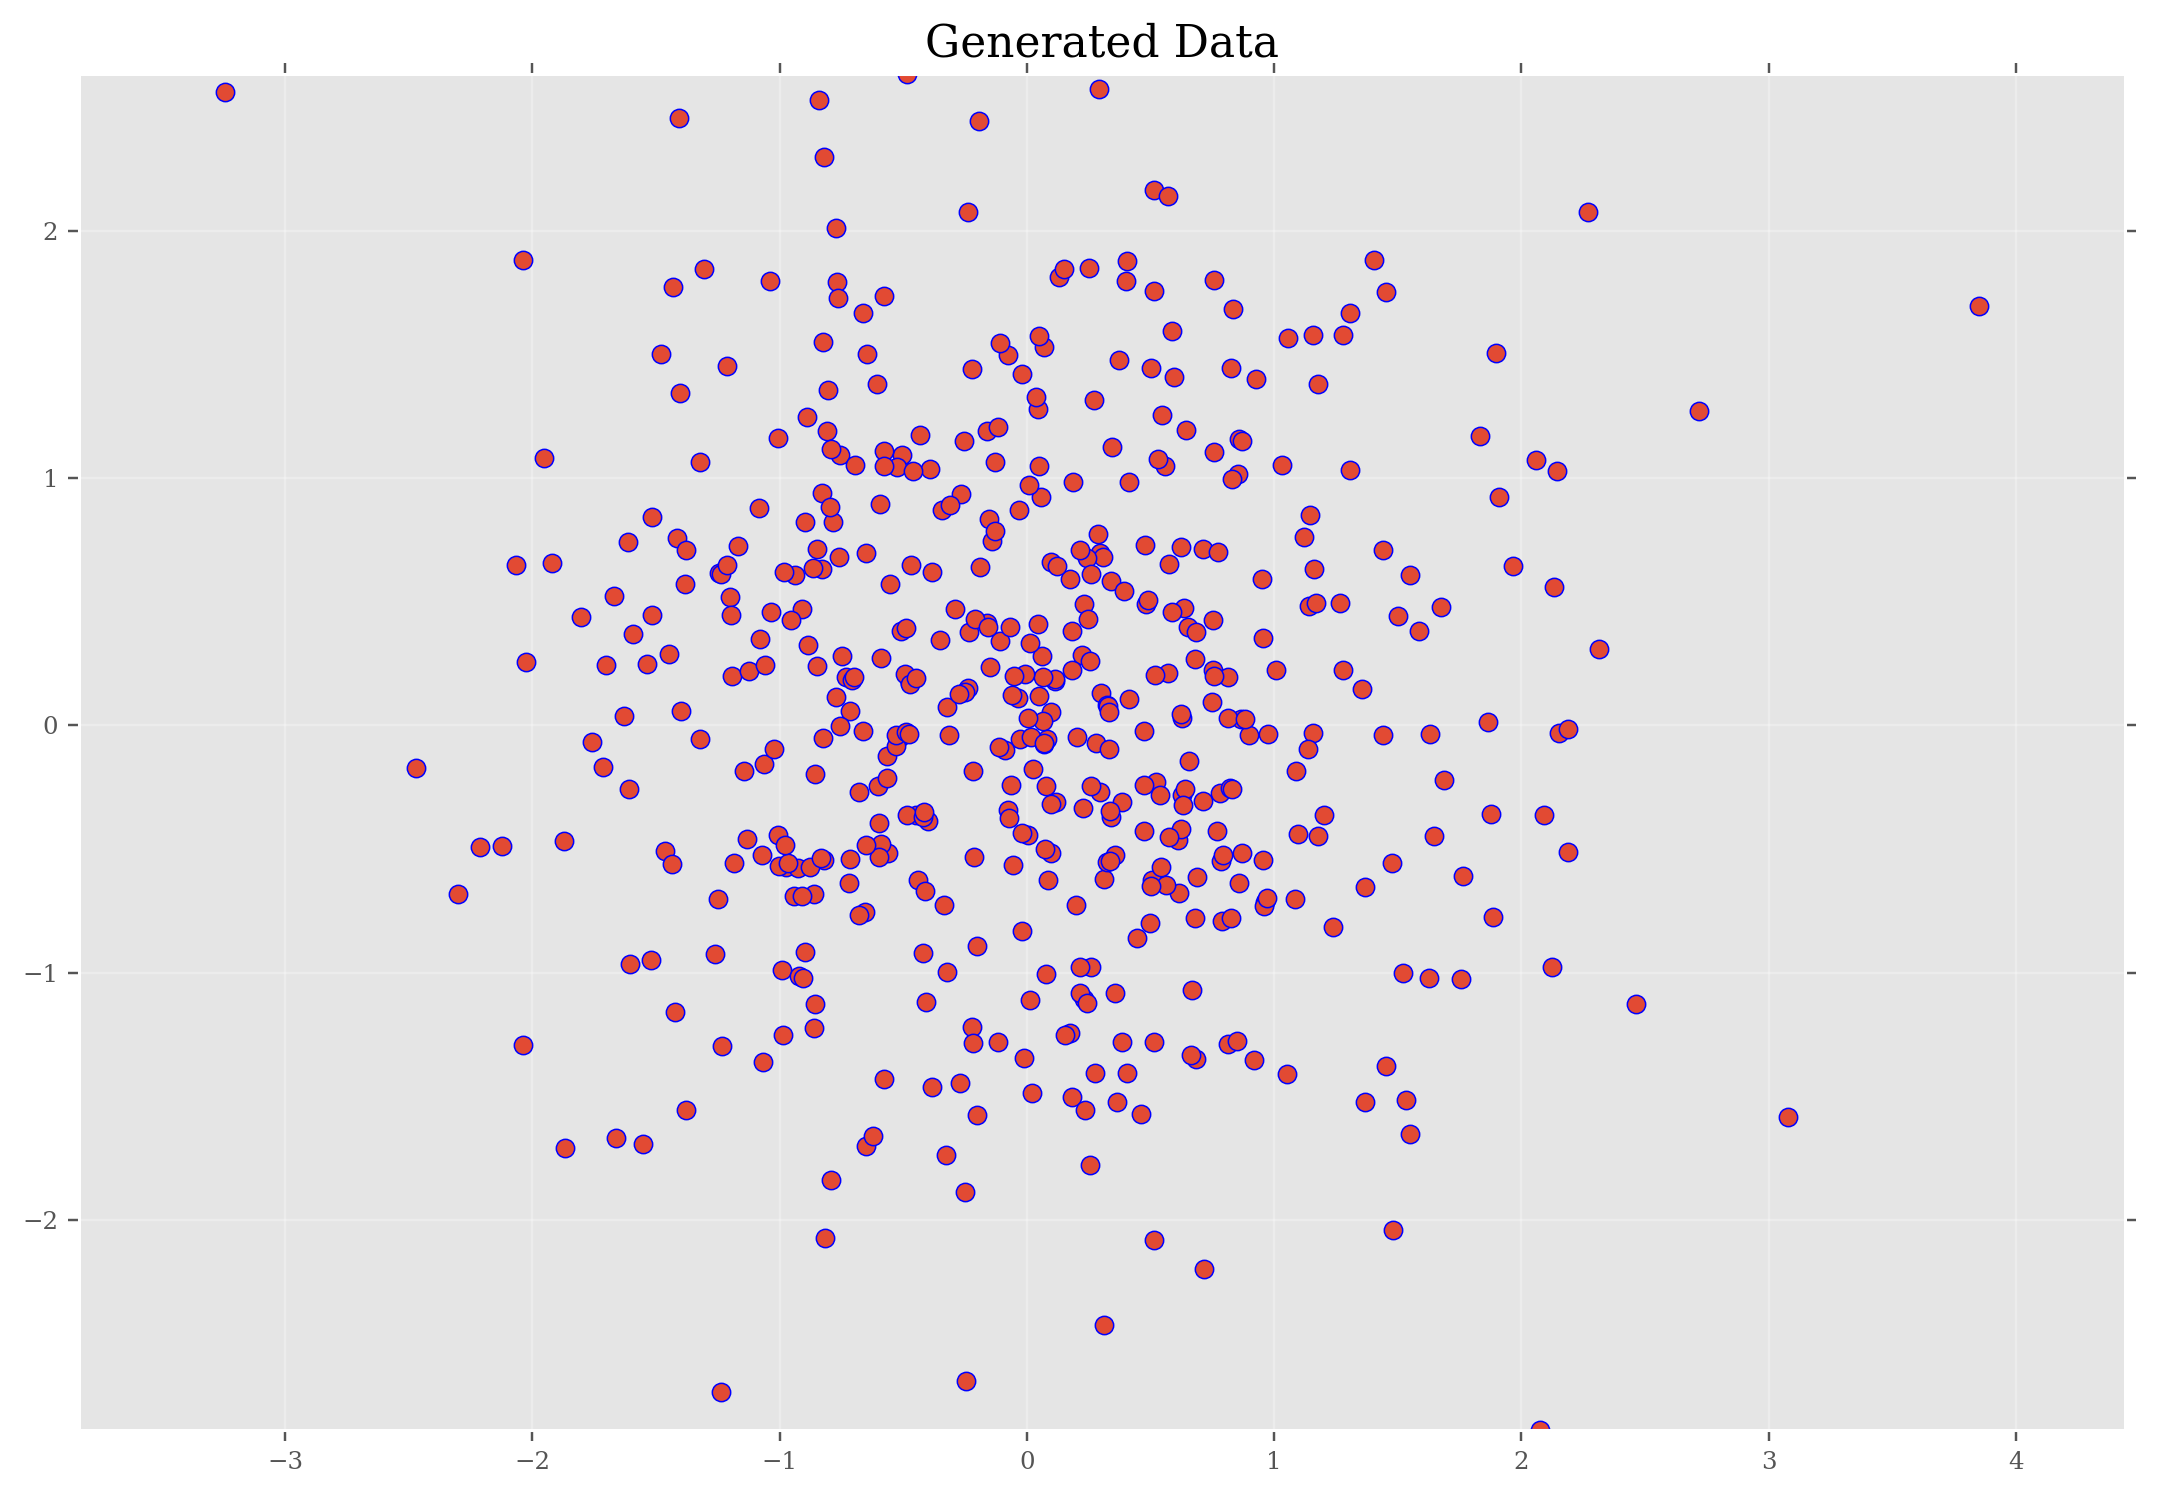

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# Normal distributed x and y vector with mean 0 and standard deviation 1
x = np.random.normal(0, 1, 500)
y = np.random.normal(0, 1, 500)
X = np.vstack((x, y)).T

plt.scatter(X[:, 0], X[:, 1])
plt.title('Generated Data')
plt.axis('equal');

In [7]:
# Covariance
def cov(x, y):
    xbar, ybar = x.mean(), y.mean()
    return np.sum((x - xbar)*(y - ybar))/(len(x) - 1)

# Covariance matrix
def cov_mat(X):
    return np.array([[cov(X[0], X[0]), cov(X[0], X[1])], \
                     [cov(X[1], X[0]), cov(X[1], X[1])]])

# Calculate covariance matrix 
cov_mat(X.T) # (or with np.cov(X.T))

array([[ 0.96858174, -0.02884604],
       [-0.02884604,  0.95699508]])

We shall adopt uniform prior distributions for $A$ and $\sigma$ and require that they
are both nonnegative, $p(A, \sigma |I ) = constant$, for $0 ≤ A < A_{max}$ and $0 ≤ \sigma < \sigma_{max}$.

This model might correspond to a spectral line of known central wavelength but with
an unknown width ($\sigma$) and strength (amplitude $A$), measured in the presence of a
background with strength $B$. It could also correspond to a profile of a source in an
image with an unknown background $B$; we know the source position and are trying
to estimate its flux ($A)$ and width ($\sigma$ ; and perhaps compare it later to the point spread
function to check if the source is resolved). 

Using the numerical methods developed, one might even imagine solving a model with all three parameters unknown: location, width, and background level. (coming soon). In the case of a known location $\mu$, the logarithm of the posterior pdf is:

$$L_{p}=ln(p(a, \sigma| x_{i}, \mu, W ))=\sum_{i=1}^{N}ln[a\frac{exp(\frac{-(x_i-\mu)^2}{2\sigma^2})}{\sqrt{2\pi}\sigma}+\frac{1-A}{W}]$$

It is not possible to analytically find $A$ and $\sigma$ corresponding to the maximum of this
posterior pdf. A numerical example, based on $N = 200$ values of $x_{i}$ , generated using
$A = 0.5, \sigma = 1, \mu = 5$, and $W = 10$ is shown

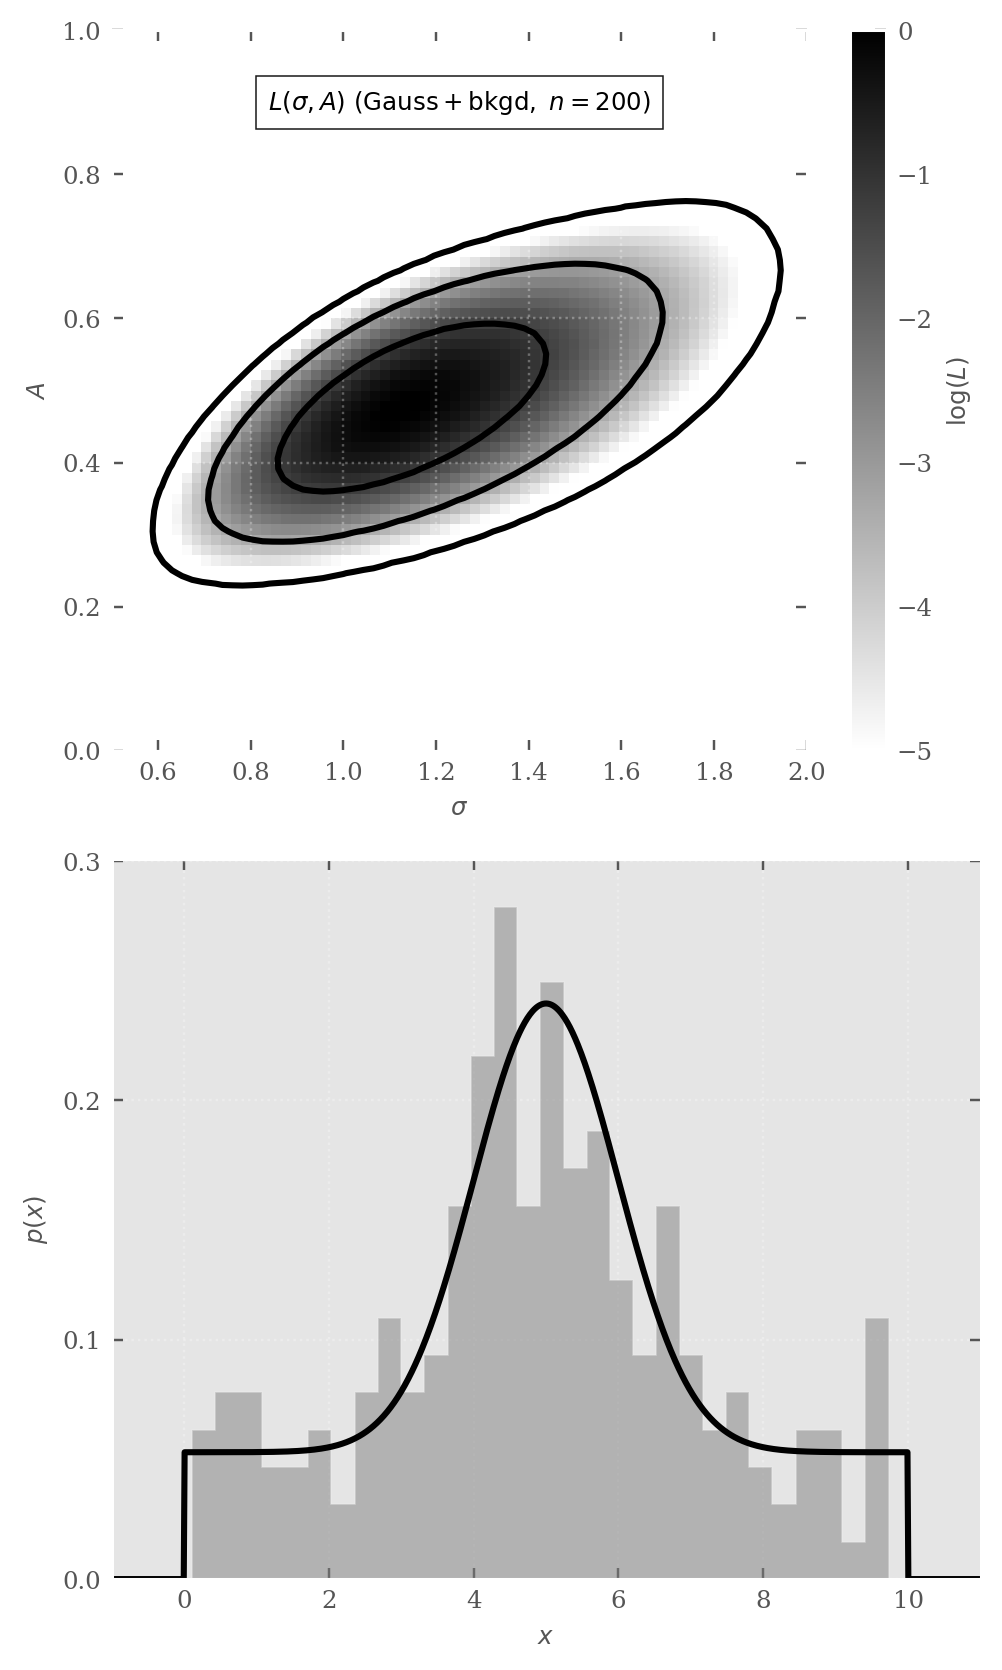

In [8]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import truncnorm, uniform
from astroML.plotting.mcmc import convert_to_stdev

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def gausslin_logL(xi, A=0.5, sigma=1.0, mu=5.0, L=10.0):
    """Equation 5.80: gaussian likelihood with uniform background"""
    xi = np.asarray(xi)

    shape = np.broadcast(sigma, A, mu, L).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return np.sum(np.log(A * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)
                         / (sigma * np.sqrt(2 * np.pi))
                         + (1. - A) / L), 0)

#------------------------------------------------------------
# Define the distribution
np.random.seed(0)
mu = 5.0
sigma = 1.0
L = 10.0
A = 0.5
N = 200

xi = np.random.random(N)
NA = np.sum(xi < A)

dist1 = truncnorm((0 - mu) / sigma, (L - mu) / sigma, mu, sigma)
dist2 = uniform(0, 10)

xi[:NA] = dist1.rvs(NA)
xi[NA:] = dist2.rvs(N - NA)

x = np.linspace(-1, 11, 1000)
fracA = NA * 1. / N

#------------------------------------------------------------
# define the (sigma, A) grid and compute logL
sigma = np.linspace(0.5, 2, 70)
A = np.linspace(0, 1, 70)

logL = gausslin_logL(xi, A[:, np.newaxis], sigma)
logL -= logL.max()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 8))
fig.subplots_adjust(bottom=0.07, left=0.11, hspace=0.15, top=0.95)

ax = fig.add_subplot(211)
plt.imshow(logL, origin='lower', aspect='auto',
           extent=(sigma[0], sigma[-1], A[0], A[-1]),
           cmap=plt.cm.binary)
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$A$')

ax.text(0.5, 0.9, r'$L(\sigma,A)\ (\mathrm{Gauss + bkgd},\ n=200)$',
        bbox=dict(ec='k', fc='w', alpha=0.9),
        ha='center', va='center', transform=plt.gca().transAxes)

ax.contour(sigma, A, convert_to_stdev(logL),
           levels=(0.683, 0.955, 0.997),
           colors='k')

ax2 = plt.subplot(212)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax2.plot(x, fracA * dist1.pdf(x) + (1. - fracA) * dist2.pdf(x), '-k')
ax2.hist(xi, 30, density=True, histtype='stepfilled', fc='gray', alpha=0.5)

ax2.set_ylim(0, 0.301)
ax2.set_xlim(-1, 11)

ax2.set_xlabel('$x$')
ax2.set_ylabel('$p(x)$')
plt.show()

As expected, there is a trade-off between $A$ and $\sigma$ : an error in $\sigma$ is compensated by a proportional error in $A$. The posterior pdfs for $A$ and $\sigma$ can be determined by marginalizing the posterior pdf. On the other hand, if additional information were available about either parameter, the other one would be better constrained. In this example, if $W$ were significantly increased, the
knowledge of the background strength, and thus of $A$ too, would be much improved.
In the limit of a perfectly known $A$, the posterior pdf for $\sigma$ would simply correspond to a slice through $L_p(A, \sigma)$ (on a linear scale and renormalized!), and would be narrower than the marginal posterior pdf for $\sigma$.

Note that our data {$x_{i}$} were never binned when computing the posterior probability. We only used the binning and histogram in the figure to visualize the simulated sample. Nevertheless, the measuring process often results in binned data (e.g., pixels in an image, or spectral measurements). If we had to solve the same problem of a Gaussian line on top of a flat background with binned data, the
computation would be similar but not identical.

The data would include counts $y_i$ for
each bin position $x_i$ . The model prediction for $y_i$ , or $p(D|M, I )$, would still be based
on eq. 5.83, and we would need to use counting (Poisson) statistics to describe the
variation around the expected count values. This example would be solved similarly
to the example discussed next.

<a id="4-regression"></a>
## 4. Regression Preview: Gaussian vs. Poissonian Likelihood

In the examples presented so far, we dealt with distributions of a single random variable. Let us now consider a problem where the data are pairs of random variables, $(x_1, y_1), \dots, (x_M, y_M)$, where $y$ represents counts in bins centered on $x$, with a constant bin width. We estimate parameters $a$ and $b$ for a linear model $y = ax + b$.

Here we illustrate how assumptions about data likelihood affect inferences about model parameters, and examine the effects of binning on inferred parameters.

### Unbinned Case
Assume a dataset $\{x_i\}$ of size $N = \sum_{j=1}^M y_j$ drawn from $p(x) = ax + b$ within $x_{\min} \le x \le x_{\max}$. With normalization $b = \frac{1}{W} - a x_{1/2}$ (where $W = x_{\max} - x_{\min}$ and $x_{1/2} = (x_{\min} + x_{\max})/2$), the single-parameter likelihood given $a$ is:

$$p(x_i \mid a, I) = a(x_i - x_{1/2}) + \frac{1}{W}$$


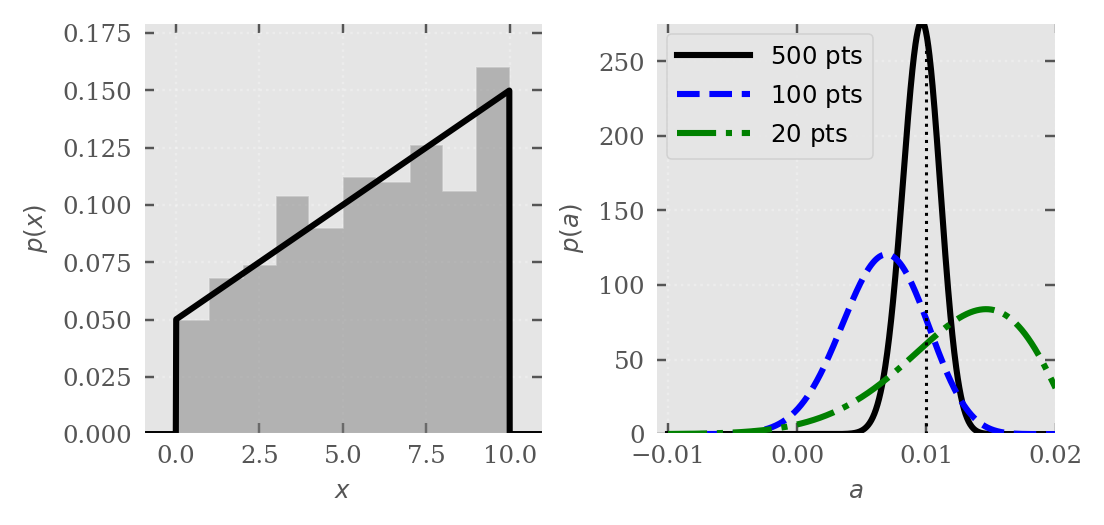

In [9]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
# Compatibility patch for astroML linear distribution with modern SciPy
from astroML.stats.random import linear, linear_gen
if not hasattr(linear_gen, '_scipy_patched'):
    def _fixed_linear_rvs(self, a, b, c, size=None, random_state=None):
        if size is None:
            size = getattr(self, '_size', 1)
        rng = np.random.default_rng(random_state)
        mu = 0.5 * (a + b)
        W = (b - a)
        x0 = 1.0 / (c * W) - mu
        r = rng.random(size)
        return -x0 + np.sqrt(2.0 * r / c + a * a + 2.0 * a * x0 + x0 * x0)
    linear_gen._rvs = _fixed_linear_rvs
    linear_gen._scipy_patched = True

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def linprob_logL(x, a, xmin, xmax):
    x = x.ravel()
    a = a.reshape(a.shape + (1,))

    mu = 0.5 * (xmin + xmax)
    W = (xmax - xmin)

    return np.sum(np.log(a * (x - mu) + 1. / W), -1)

#----------------------------------------------------------------------
# Draw the data from the linear distribution
np.random.seed(0)

N = 500

a_true = 0.01
xmin = 0.0
xmax = 10.0

lin_dist = linear(xmin, xmax, a_true)
data = lin_dist.rvs(N)
x = np.linspace(xmin - 1, xmax + 1, 1000)
px = lin_dist.pdf(x)

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 2.5))
fig.subplots_adjust(left=0.12, right=0.95, wspace=0.28,
                    bottom=0.15, top=0.9)

# left panel: plot the model and a histogram of the data
ax1 = fig.add_subplot(121)
ax1.hist(data, bins=np.linspace(0, 10, 11), density=True,
         histtype='stepfilled', fc='gray', alpha=0.5)
ax1.plot(x, px, '-k')
ax1.set_xlim(-1, 11)
ax1.set_ylim(0, 0.18)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$p(x)$')

# right panel: construct and plot the likelihood
ax2 = fig.add_subplot(122)
ax2.xaxis.set_major_locator(plt.MultipleLocator(0.01))

a = np.linspace(-0.01, 0.02, 1000)
Npts = (500, 100, 20)
styles = ('-k', '--b', '-.g')

for n, s in zip(Npts, styles):
    logL = linprob_logL(data[:n], a, xmin, xmax)
    logL = np.exp(logL - logL.max())
    logL /= logL.sum() * (a[1] - a[0])

    ax2.plot(a, logL, s, label=r'$\rm %i\ pts$' % n)
ax2.legend(loc=2, prop=dict(size=8))

ax2.set_xlim(-0.011, 0.02)

ax2.set_xlabel('$a$')
ax2.set_ylabel('$p(a)$')

# vertical line: in newer matplotlib versions, use ax.vlines([a_true])
ylim = ax2.get_ylim()
ax2.plot([a_true, a_true], ylim, ':k', lw=1)
ax2.set_ylim(ylim)

plt.show()


### Binned Data: Gaussian Approximation vs. Exact Poisson Likelihood

The model predicting the expected count in bin $i$, $y(x_i) = a^* x_i + b^*$, is:
$$y(x) = Y \int_{x - \Delta/2}^{x + \Delta/2} p(x) \, dx$$

#### Gaussian Approximation ($L_p^G$):
When counts per bin $\mu_i$ are sufficiently large, the likelihood is approximately Gaussian with $\sigma_i = \sqrt{\mu_i}$. With uniform priors on $a^*$ and $b^*$, the log-posterior is:

$$L_p^G(a^*, b^*) = \ln p(a^*, b^* \mid \{x_i, y_i\}) = \text{constant} - \frac{1}{2} \sum_{i=1}^M \left[ \ln(a^* x_i + b^*) + \frac{(y_i - a^* x_i - b^*)^2}{a^* x_i + b^*} \right]$$

#### Poisson Likelihood ($L_p^P$):
When count numbers are small, the exact Poisson distribution $p(k \mid \mu_i) = \mu_i^k e^{-\mu_i}/k!$ must be used:

$$L_p^P(a^*, b^*) = \text{constant} + \sum_{i=1}^M \left[ y_i \ln(a^* x_i + b^*) - (a^* x_i + b^*) \right]$$


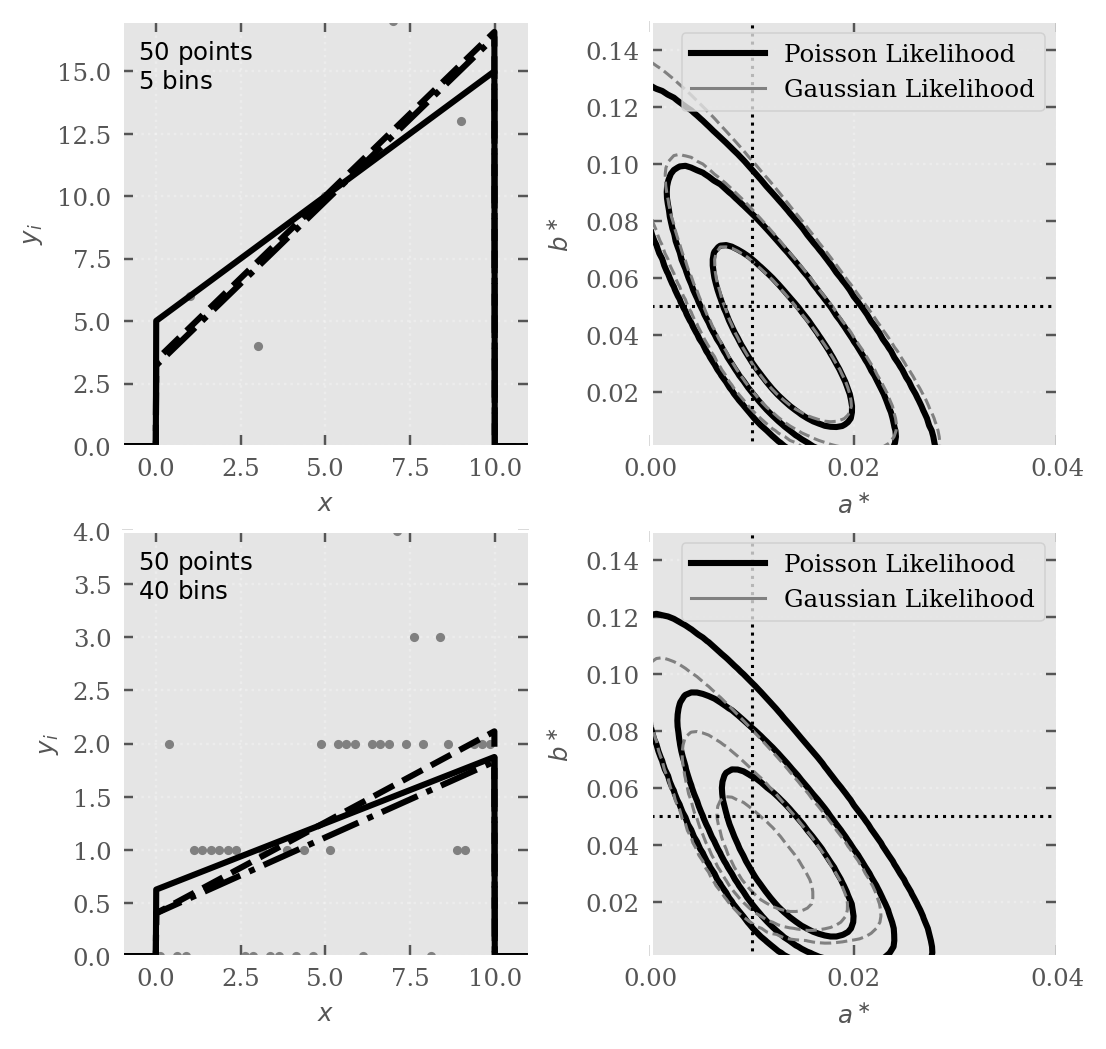

In [10]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats, interpolate
# Compatibility patch for astroML linear distribution with modern SciPy
from astroML.stats.random import linear, linear_gen
if not hasattr(linear_gen, '_scipy_patched'):
    def _fixed_linear_rvs(self, a, b, c, size=None, random_state=None):
        if size is None:
            size = getattr(self, '_size', 1)
        rng = np.random.default_rng(random_state)
        mu = 0.5 * (a + b)
        W = (b - a)
        x0 = 1.0 / (c * W) - mu
        r = rng.random(size)
        return -x0 + np.sqrt(2.0 * r / c + a * a + 2.0 * a * x0 + x0 * x0)
    linear_gen._rvs = _fixed_linear_rvs
    linear_gen._scipy_patched = True
from astroML.plotting.mcmc import convert_to_stdev

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def logL_gaussian(xi, yi, a, b):
    """gaussian log-likelihood (Eq. 5.87)"""
    xi = xi.ravel()
    yi = yi.ravel()
    a = a.reshape(a.shape + (1,))
    b = b.reshape(b.shape + (1,))
    yyi = a * xi + b
    return -0.5 * np.sum(np.log(yyi) + (yi - yyi) ** 2 / yyi, -1)


def logL_poisson(xi, yi, a, b):
    """poisson log-likelihood (Eq. 5.88)"""
    xi = xi.ravel()
    yi = yi.ravel()
    a = a.reshape(a.shape + (1,))
    b = b.reshape(b.shape + (1,))
    yyi = a * xi + b

    return np.sum(yi * np.log(yyi) - yyi, -1)


#------------------------------------------------------------
# Draw points from distribution
np.random.seed(0)

N = 50

a_true = 0.01
xmin = 0.0
xmax = 10.0
b_true = 1. / (xmax - xmin) - 0.5 * a_true * (xmax + xmin)

lin_dist = linear(xmin, xmax, a_true)
data = lin_dist.rvs(N)

#------------------------------------------------------------
# Compute and plot the results
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.3,
                    bottom=0.1, top=0.95, hspace=0.2)

a = np.linspace(0.00001, 0.04, 71)
b = np.linspace(0.00001, 0.15, 71)

for num, nbins in enumerate([5, 40]):
    # divide points into bins
    yi, bins = np.histogram(data, bins=np.linspace(xmin, xmax, nbins + 1))
    xi = 0.5 * (bins[:-1] + bins[1:])

    # compute likelihoods for Poisson and Gaussian models
    factor = N * (xmax - xmin) * 1. / nbins
    LP = logL_poisson(xi, yi, factor * a, factor * b[:, None])
    LG = logL_gaussian(xi, yi, factor * a, factor * b[:, None])

    LP -= np.max(LP)
    LG -= np.max(LG)

    # find maximum likelihood point
    i, j = np.where(LP == np.max(LP))
    aP, bP = a[j[0]], b[i[0]]

    i, j = np.where(LG == np.max(LG))
    aG, bG = a[j[0]], b[i[0]]

    # plot scatter and lines
    ax = fig.add_subplot(2, 2, 1 + 2 * num)
    plt.scatter(xi, yi, s=9, c='gray', lw=0)

    x = np.linspace(xmin - 1, xmax + 1, 1000)
    for (ai, bi, s) in [(a_true, b_true, '-k'),
                        (aP, bP, '--k'),
                        (aG, bG, '-.k')]:
        px = ai * x + bi
        px[x < xmin] = 0
        px[x > xmax] = 0
        ax.plot(x, factor * px, s)

    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y_i$')

    ax.text(0.04, 0.96,
            r'$\rm %i\ points$' % N + '\n' + r'$\rm %i\ bins$' % nbins,
            ha='left', va='top', transform=ax.transAxes)

    # plot likelihood contours
    ax = fig.add_subplot(2, 2, 2 + 2 * num)

    ax.contour(a, b, convert_to_stdev(LP),
               levels=(0.683, 0.955, 0.997),
               colors='k', linewidths=2)

    ax.contour(a, b, convert_to_stdev(LG),
               levels=(0.683, 0.955, 0.997),
               colors='gray', linewidths=1, linestyles='dashed')

    # trick the legend command
    ax.plot([0], [0], '-k', lw=2, label='Poisson Likelihood')
    ax.plot([0], [0], '-', c='gray', lw=1, label='Gaussian Likelihood')
    ax.legend(loc=1)

    # plot horizontal and vertical lines
    #  in newer matplotlib versions, use ax.vlines() and ax.hlines()
    ax.plot([a_true, a_true], [0, 0.2], ':k', lw=1)
    ax.plot([0, 0.06], [b_true, b_true], ':k', lw=1)

    ax.set_xlabel(r'$a^\ast$')
    ax.set_ylabel(r'$b^\ast$')

    ax.set_xlim(0, 0.04)
    ax.set_ylim(0.001, 0.15)

    ax.xaxis.set_major_locator(plt.MultipleLocator(0.02))

plt.show()


Figure compares $L^G_p$ and $L^P_p$ . When the counts in each bin are high, the Gaussian expression $L^G_p$ is a good approximation of the true likelihood $L^P_p$. When
there are fewer counts per bin, the Gaussian approximation becomes biased toward
smaller a and b. The difference is not large however: the expectation value and
standard deviation for $y_i$ is the same for the Poisson and Gaussian case. It is only
the shape of the distribution that changes.

Note also in figure  that there is a correlation between the best-fit parameters: i.e., the posterior probability contours in the ($a^∗ , b^∗$) plane are not aligned with
the coordinate axes. The orientation of the semimajor axis reflects the normalization constraint for the underlying pdf.

$$b^*=\frac{Y\Delta}{W}-a^*x_{1/2}$$

Finally, we would expect that as the number of bins becomes very large, the solution would approach that of the unbinned case. In the next figure, we compare the
marginalized distribution for a in the unbinned case and the binned case with 1000
bins. The results are nearly identical, as expected.

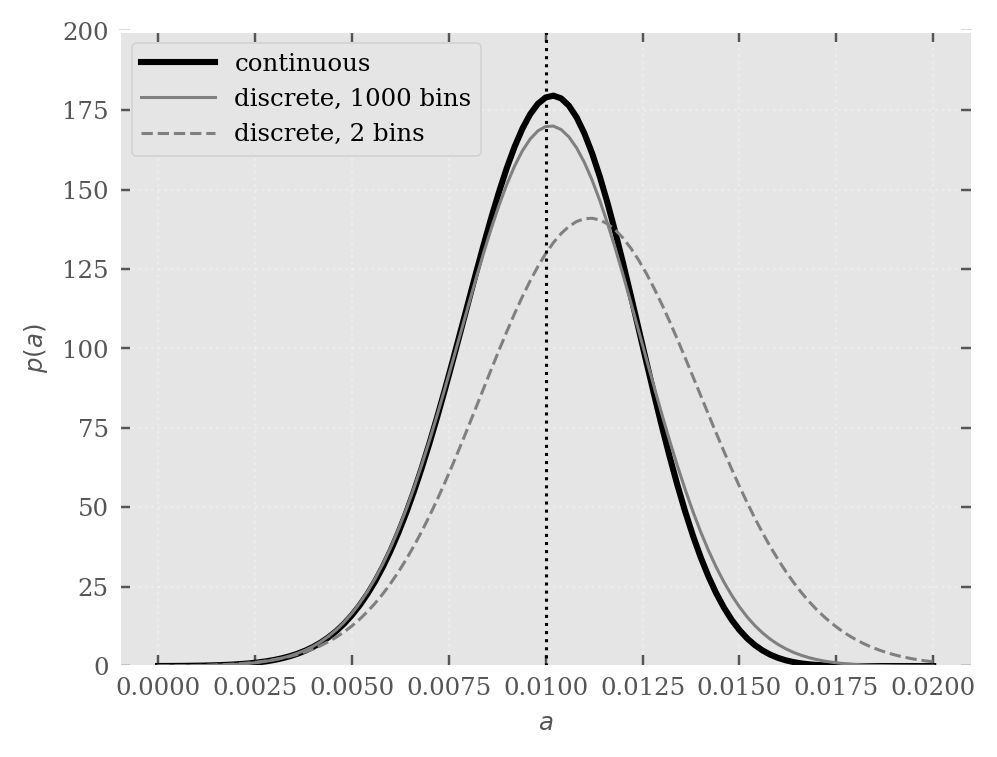

In [11]:
"""
Poisson Statistics with arbitrarily small bins
----------------------------------------------
Figure 5.16
The comparison of the continuous method (figure 5.14) and the binned method
(figure 5.15) on the same data set. In the limit of a large number of bins,
most bins register only zero or one count, and the binned Poisson statistic
gives nearly the same marginalized distribution for a as the continuous
statistic. For as few as two bins, the constraint on the slope is only
slightly biased.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
# Compatibility patch for astroML linear distribution with modern SciPy
from astroML.stats.random import linear, linear_gen
if not hasattr(linear_gen, '_scipy_patched'):
    def _fixed_linear_rvs(self, a, b, c, size=None, random_state=None):
        if size is None:
            size = getattr(self, '_size', 1)
        rng = np.random.default_rng(random_state)
        mu = 0.5 * (a + b)
        W = (b - a)
        x0 = 1.0 / (c * W) - mu
        r = rng.random(size)
        return -x0 + np.sqrt(2.0 * r / c + a * a + 2.0 * a * x0 + x0 * x0)
    linear_gen._rvs = _fixed_linear_rvs
    linear_gen._scipy_patched = True

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def logL_continuous(x, a, xmin, xmax):
    """Continuous log-likelihood (Eq. 5.84)"""
    x = x.ravel()
    a = a.reshape(a.shape + (1,))

    mu = 0.5 * (xmin + xmax)
    W = (xmax - xmin)

    return np.sum(np.log(a * (x - mu) + 1. / W), -1)


def logL_poisson(xi, yi, a, b):
    """poisson log-likelihood (Eq. 5.88)"""
    xi = xi.ravel()
    yi = yi.ravel()
    a = a.reshape(a.shape + (1,))
    b = b.reshape(b.shape + (1,))
    yyi = a * xi + b
    return np.sum(yi * np.log(yyi) - yyi, -1)

#----------------------------------------------------------------------
# draw the data
np.random.seed(0)
N = 200
a_true = 0.01
xmin = 0.0
xmax = 10.0

lin_dist = linear(xmin, xmax, a_true)
x = lin_dist.rvs(N)

a = np.linspace(0.0, 0.02, 101)
b = np.linspace(0.00001, 0.15, 51)

#------------------------------------------------------------
# Compute the log-likelihoods

# continuous case
logL = logL_continuous(x, a, xmin, xmax)
L_c = np.exp(logL - logL.max())
L_c /= L_c.sum() * (a[1] - a[0])

# discrete case: compute for 2 and 1000 bins
nbins = [1000, 2]
L_p = [0, 0]

for i, n in enumerate(nbins):
    yi, bins = np.histogram(x, bins=np.linspace(xmin, xmax, n + 1))
    xi = 0.5 * (bins[:-1] + bins[1:])

    factor = N * (xmax - xmin) * 1. / n

    logL = logL_poisson(xi, yi, factor * a, factor * b[:, None])
    L_p[i] = np.exp(logL - np.max(logL)).sum(0)
    L_p[i] /= L_p[i].sum() * (a[1] - a[0])


#------------------------------------------------------------
# Plot the results
fig, ax = plt.subplots(figsize=(5, 3.75))

ax.plot(a, L_c, '-k', label='continuous')
for L, ls, n in zip(L_p, ['-', '--'], nbins):
    ax.plot(a, L, ls, color='gray', lw=1,
            label='discrete, %i bins' % n)

# plot a vertical line: in newer matplotlib, use ax.vlines([a_true])
ylim = (0, 200)
ax.plot([a_true, a_true], ylim, ':k', lw=1)

ax.set_xlim(-0.001, 0.021)
ax.set_ylim(ylim)

ax.set_xlabel('$a$')
ax.set_ylabel('$p(a)$')

ax.legend(loc=2)

plt.show()


<a id="5-outliers"></a>
## 5. Mixture Models: Dealing with Outliers and Bad Data Points

When the data contain unreliable measurements (outliers drawn from a distribution with much larger width $\sigma^*$), we can construct a **mixture model** using latent binary indicator variables $g_i \in \{0, 1\}$:

$$p(x_i \mid \mu, \sigma_i, g_i, I) = g_i \, \mathcal{N}(\mu, \sigma_i) + (1 - g_i) \, p_{\text{bad}}(x_i \mid \mu, I)$$

Here $g_i = 1$ indicates a good point, while $g_i = 0$ indicates an outlier drawn from $p_{\text{bad}}(x_i \mid \mu, I) = \mathcal{N}(\mu, \sigma^*)$, where $\sigma^* \gg \sigma_i$.

Treating $\{g_i\}$ as nuisance parameters and marginalizing over them gives the joint likelihood:

$$p(\mu \mid \{x_i\}, \{\sigma_i\}) \propto \prod_{i=1}^{N} \left[ \mathcal{N}(\mu, \sigma_i) + \mathcal{N}(\mu, \sigma^*) \right]$$

Crucially, in the Bayesian framework we can also marginalize over $\mu$ and all $g_j$ except for one point $g_k$, obtaining the **posterior probability that a specific point $x_k$ is an outlier**:

$$p(\mu, g_1 \mid \{x_i\}, \{\sigma_i\}) = \left[ g_1 \mathcal{N}(\mu, \sigma_1) + (1 - g_1) \mathcal{N}(\mu, \sigma^*) \right] \prod_{i=2}^{N} \left[ \mathcal{N}(\mu, \sigma_i) + \mathcal{N}(\mu, \sigma^*) \right]$$


<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_3992773/1138414551.py:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  The left panel shows a point identified as bad (:math:`\hat{g_i|} = 0`),


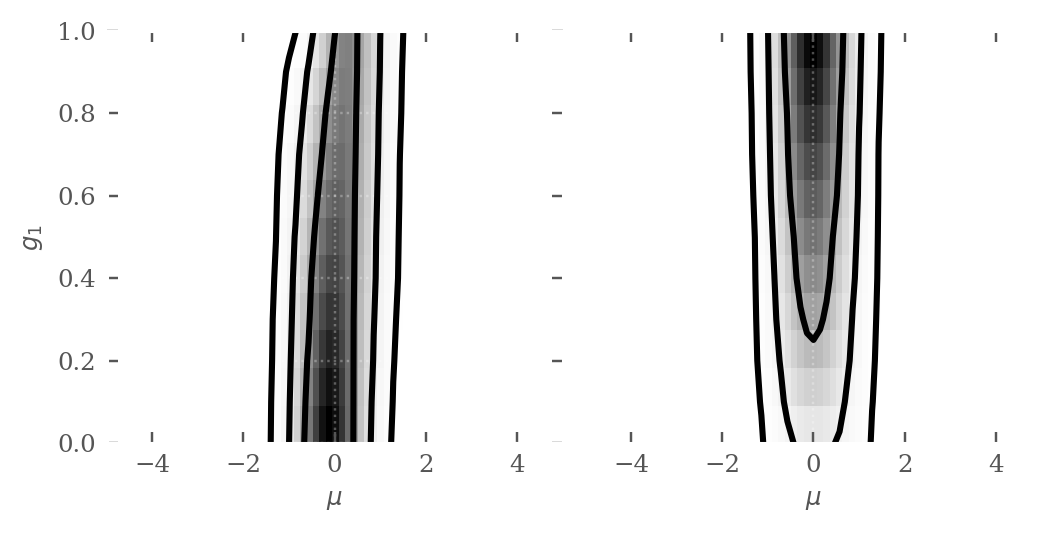

In [12]:
"""
Plot the posterior of mu vs g1 with outliers
--------------------------------------------
Figure 5.17
The marginal joint distribution between mu and g_i, as given by eq. 5.100.
The left panel shows a point identified as bad (:math:`\hat{g_i|} = 0`),
while the right panel shows a point identified as good(:math:`\hat{g_i|} = 1`).
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from astroML.plotting.mcmc import convert_to_stdev

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def p(mu, g1, xi, sigma1, sigma2):
    """Equation 5.97: marginalized likelihood over outliers"""
    L = (g1 * norm.pdf(xi[0], mu, sigma1) +
         (1 - g1) * norm.pdf(xi[0], mu, sigma2))

    mu = mu.reshape(mu.shape + (1,))
    g1 = g1.reshape(g1.shape + (1,))

    return L * np.prod(norm.pdf(xi[1:], mu, sigma1)
                       + norm.pdf(xi[1:], mu, sigma2), -1)

#------------------------------------------------------------
# Sample the points
np.random.seed(138)

N1 = 8
N2 = 2
sigma1 = 1
sigma2 = 3

sigmai = np.zeros(N1 + N2)
sigmai[N2:] = sigma1
sigmai[:N2] = sigma2

xi = np.random.normal(0, sigmai)

#------------------------------------------------------------
# Compute the marginalized posterior for the first and last point
mu = np.linspace(-5, 5, 71)
g1 = np.linspace(0, 1, 11)

L1 = p(mu[:, None], g1, xi, 1, 10)
L1 /= np.max(L1)

L2 = p(mu[:, None], g1, xi[::-1], 1, 10)
L2 /= np.max(L2)

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 2.5))
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.05,
                    bottom=0.15, top=0.9)

ax1 = fig.add_subplot(121)
ax1.imshow(L1.T, origin='lower', aspect='auto', cmap=plt.cm.binary,
           extent=[mu[0], mu[-1], g1[0], g1[-1]])
ax1.contour(mu, g1, convert_to_stdev(np.log(L1).T),
            levels=(0.683, 0.955, 0.997),
            colors='k')
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$g_1$')

ax2 = fig.add_subplot(122)
ax2.imshow(L2.T, origin='lower', aspect='auto', cmap=plt.cm.binary,
           extent=[mu[0], mu[-1], g1[0], g1[-1]])
ax2.contour(mu, g1, convert_to_stdev(np.log(L2).T),
            levels=(0.683, 0.955, 0.997),
            colors='k')
ax2.set_xlabel(r'$\mu$')
ax2.yaxis.set_major_locator(plt.NullLocator())

plt.show()

<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_3992773/3988588203.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  conditioned on :math:`\mu = \mu_0`, the MAP estimate of :math:`\mu` (eq. 5.102)


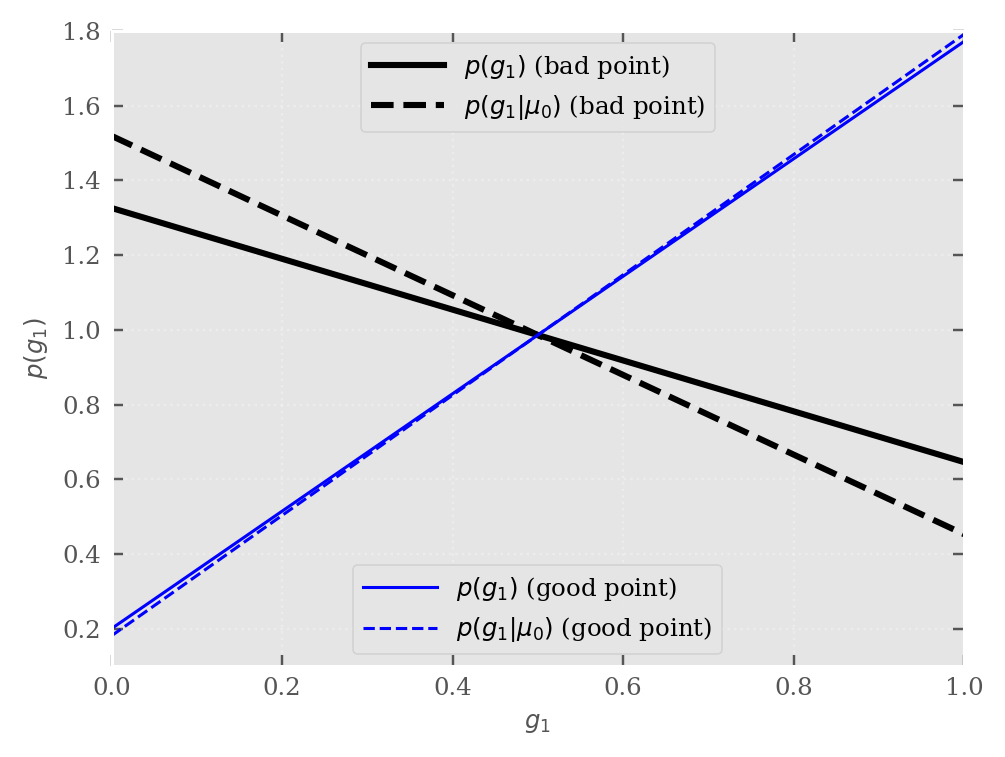

In [13]:
"""
Plot the Outlier Probability
----------------------------
Figure 5.18
The marginal probability for g_i for the "good" and "bad" points shown in
figure 5.17. The solid curves show the marginalized probability: that is,
eq. 5.100 is integrated over mu. The dashed curves show the probability
conditioned on :math:`\mu = \mu_0`, the MAP estimate of :math:`\mu` (eq. 5.102)
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


def p(mu, g1, xi, sigma1, sigma2):
    """Equation 5.97: marginalized likelihood over outliers"""
    L = (g1 * norm.pdf(xi[0], mu, sigma1) +
         (1 - g1) * norm.pdf(xi[0], mu, sigma2))

    mu = mu.reshape(mu.shape + (1,))
    g1 = g1.reshape(g1.shape + (1,))

    return L * np.prod(norm.pdf(xi[1:], mu, sigma1)
                       + norm.pdf(xi[1:], mu, sigma2), -1)

#------------------------------------------------------------
# Sample the points
np.random.seed(138)

N1 = 8
N2 = 2
sigma1 = 1
sigma2 = 3

sigmai = np.zeros(N1 + N2)
sigmai[N2:] = sigma1
sigmai[:N2] = sigma2

xi = np.random.normal(0, sigmai)

#------------------------------------------------------------
# Compute the marginalized posterior for the first and last point
mu = np.linspace(-5, 5, 71)
g1 = np.linspace(0, 1, 71)

L1 = p(mu[:, None], g1, xi, 1, 10)
L1 /= np.max(L1)

(i1, j1) = np.where(L1 == 1)
mu0_1 = mu[i1]


L2 = p(mu[:, None], g1, xi[::-1], 1, 10)
L2 /= np.max(L2)
(i2, j2) = np.where(L2 == 1)
mu0_2 = mu[i2]

p1 = L1.sum(0)
p2 = L2.sum(0)

p1 /= np.sum(p1) * (g1[1] - g1[0])
p2 /= np.sum(p2) * (g1[1] - g1[0])

p1a = L1[i1[0]]
p2a = L2[i2[0]]

p1a /= p1a.sum() * (g1[1] - g1[0])
p2a /= p2a.sum() * (g1[1] - g1[0])

#------------------------------------------------------------
# Plot the results
fig, ax = plt.subplots(figsize=(5, 3.75))

l1, = ax.plot(g1, p1, '-k', lw=2)
l2, = ax.plot(g1, p1a, '--k', lw=2)
leg1 = ax.legend([l1, l2],
                 [r'$p(g_1)$ (bad point)',
                  r'$p(g_1|\mu_0)$ (bad point)'], loc=9)

l3, = ax.plot(g1, p2, '-b', lw=1, label=r'$p(g_1)$ (good point)')
l4, = ax.plot(g1, p2a, '--b', lw=1, label=r'$p(g_1|\mu_0)$ (good point)')
leg2 = ax.legend([l3, l4],
                 [r'$p(g_1)$ (good point)',
                  r'$p(g_1|\mu_0)$ (good point)'], loc=8)

# trick to display two legends:
# when legend() is called the second time, the first one is removed from
# the axes.  We add it back in here:
ax.add_artist(leg1)

ax.set_xlabel('$g_1$')
ax.set_ylabel('$p(g_1)$')

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.8)

plt.show()

<a id="6-exercises"></a>
## 6. Hands-On Student Exercises & Summary

### Exercise 1: Robust Inference in the Presence of Outliers
1. In the MCMC cell above, artificially add a severe outlier to the data array:
   ```python
   data_corrupted = np.append(data, [25.0])
   ```
2. Re-run `emcee` using the standard Gaussian likelihood. How much does $\mu$ shift?
3. Replace the Gaussian likelihood with a **Student-t distribution** with $\nu = 3$ degrees of freedom (or the mixture model from Section 5):
   ```python
   stats.t.logpdf(data_corrupted, df=3, loc=mu, scale=sigma).sum()
   ```
4. Observe how the heavy-tailed Student-t likelihood effectively downweights the outlier and recovers the true $\mu$.

### Exercise 2: Credible Intervals — Analytical vs. MCMC
For the clean sample $N=30$, compare:
1. The analytical $68.3\%$ credible interval for $\mu$ derived from the Student-t distribution ($df = N - 1$).
2. The empirical 16th and 84th percentiles computed from `np.percentile(flat_samples[:, 0], [16, 84])`.
*Do both approaches agree within Monte Carlo sampling error?*

---
### Key Takeaways
* **Bayesian inference** treats model parameters as random variables and quantifies their posterior probability distributions conditional on data and prior knowledge.
* **Priors matter most when $N$ is small:** As sample size $N$ increases, the likelihood dominates and the posterior converges to the Maximum Likelihood Estimate (MLE).
* **Nuisance parameters** (such as $\sigma$ or outlier indicator weights $g_i$) are eliminated systematically through **marginalization** (integration).
* **Grid evaluation** provides visual intuition in 1D and 2D, while **MCMC sampling** provides the scalable foundation for modern high-dimensional inference.
